# Tugas Resampling dan visualisasi data audio

## 1. Import Library & Persiapan Lingkungan

Pustaka yang digunakan dalam modul ini mencakup ekosistem saintifik dan pengolahan audio modern Python:
- `numpy`: Manipulasi array numerik sinyal dan fungsi matematis.
- `matplotlib.pyplot`: Visualisasi bentuk gelombang (*waveform*), spektrum FFT, dan spektrogram.
- `scipy.signal`: Pemrosesan sinyal digital (filter Butterworth IIR, polyphase resampling FIR, dan sintesis sinyal *chirp*).
- `librosa`: Ekstraksi audio, analisis MIR (*Music Information Retrieval*), dan resampling standar industri.
- `IPython.display`: Pemutar audio interaktif (*playback*) di dalam notebook.
- `soundfile`: Pembaca dan penyimpan berkas audio WAV/FLAC.


In [1]:
# library standar untuk mengolah data angka dan visualisasi
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# library untuk pemrosesan data audio
import librosa
import librosa.display
import IPython.display as ipd
from IPython.display import display, Audio
import soundfile as sf
import os

# Konfigurasi visualisasi agar tajam, rapi, dan konsisten
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

print("✅ Seluruh pustaka DSP dan Audio berhasil dimuat!")


✅ Seluruh pustaka DSP dan Audio berhasil dimuat!


### Study case untuk meredam kebisingan dari suara statis




Mengunduh sampel speech dari pustaka resmi LibriSpeech...
File sampel       : /root/.cache/librosa/5703-47212-0000.ogg
Laju sampel asli  : 22050 Hz
Total sampel data : 176400 sampel (8.00 detik)


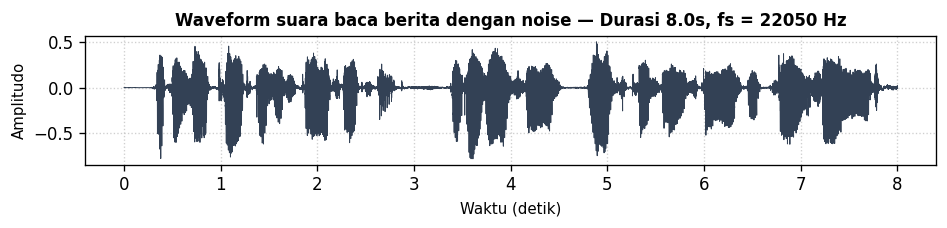

suara dengan noise statis


In [2]:
# Definisikan dulu file dengan noise statis
possible_paths = [
    'audio_testing.wav'
]
audio_path = next((p for p in possible_paths if os.path.exists(p)), None)

if audio_path is None:
    print("Mengunduh sampel speech dari pustaka resmi LibriSpeech...")
    audio_path = librosa.ex('libri1')

# Muat cuplikan 8 detik
y_speech, sr_speech = librosa.load(audio_path, sr=None, duration=8.0)

print(f"File sampel       : {audio_path}")
print(f"Laju sampel asli  : {sr_speech} Hz")
print(f"Total sampel data : {len(y_speech)} sampel ({len(y_speech)/sr_speech:.2f} detik)")

# Visualisasi waveform kecil rekaman suara manusia
fig, ax = plt.subplots(figsize=(8, 2))
t_speech = np.linspace(0, len(y_speech) / sr_speech, len(y_speech))
ax.plot(t_speech, y_speech, color='#334155', lw=0.6)
ax.set_title(f"Waveform suara baca berita dengan noise — Durasi {len(y_speech)/sr_speech:.1f}s, fs = {sr_speech} Hz", fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Amplitudo", fontsize=9)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Suara dengan noise statis
print("suara dengan noise statis")
display(ipd.Audio(y_speech, rate=sr_speech))


Dilihat dari waveform maka seseorang tersebut mulai membaca berita dimulai sekitar detik ke - 1,5 second lebih

### waveform



## Visualisasi data audio dengan FFT
untuk membedakan bagian mana yang noise statis dan informasi berita dari suara tersebut

**Apa yang kode di bawah ini kerjain?**

- `spectrum_dbfs()` pakai `scipy.signal.welch` buat ngitung rata-rata spektrum daya sepanjang sinyal (ini metode Welch — dipecah jadi banyak segmen kecil pakai window Hann, dihitung FFT tiap segmen, terus dirata-ratakan). Hasilnya lebih stabil/gak berisik dibanding FFT sekali tembak ke seluruh sinyal.
- Dikonversi ke **dBFS** (`20*log10(...)`) biar levelnya gampang dibaca — 0 dB = level maksimum digital, makin negatif makin lemah.
- Lima **ZONA** (Sub-Bass, Bass, Midrange, Presence, Treble) itu cuma pembagian rentang frekuensi yang biasa dipakai orang audio buat "nge-map" telinga kita denger apa di frekuensi berapa — bukan hasil perhitungan, cuma referensi visual biar gampang baca plotnya.


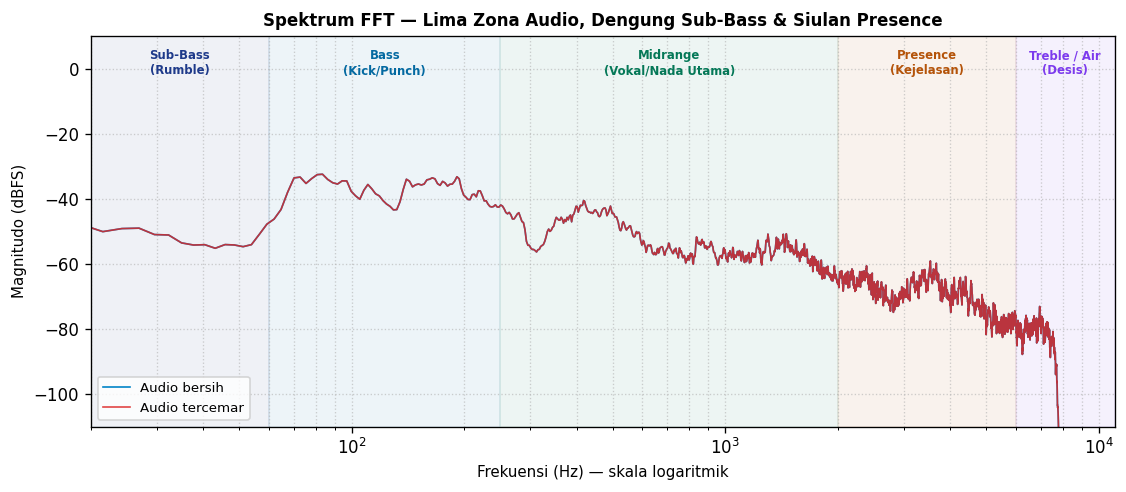

In [3]:
from scipy.signal import welch

def spectrum_dbfs(y, sr, n_fft):
    freqs, psd = welch(y, fs=sr, window='hann', nperseg=n_fft,
                        noverlap=n_fft // 2, scaling='spectrum', detrend=False)
    dbfs = 20 * np.log10(np.maximum(np.sqrt(psd), 1e-12))
    return freqs, dbfs


N_FFT_SPEC = 8192

y_clean = y_speech
sr = sr_speech

C_SIGNAL = '#0284c7'
C_ALERT = '#dc2626'
WHINE_FREQ = 2000

freqs, db_clean = spectrum_dbfs(y_clean, sr, N_FFT_SPEC)
_,     db_dirty = spectrum_dbfs(y_speech, sr, N_FFT_SPEC)

ZONA = [
    (20,   60,    'Sub-Bass\n(Rumble)',           '#1e3a8a'),
    (60,   250,   'Bass\n(Kick/Punch)',           '#0369a1'),
    (250,  2000,  'Midrange\n(Vokal/Nada Utama)', '#047857'),
    (2000, 6000,  'Presence\n(Kejelasan)',        '#b45309'),
    (6000, 11025, 'Treble / Air\n(Desis)',        '#7c3aed'),
]

fig, ax = plt.subplots(figsize=(9.5, 4.2))

for f_lo, f_hi, label, warna in ZONA:
    ax.axvspan(f_lo, f_hi, color=warna, alpha=0.07)
    ax.text(np.sqrt(f_lo * f_hi), 6, label, ha='center', va='top',
            fontsize=7, fontweight='bold', color=warna)

for db, warna, label, alpha in [(db_clean, C_SIGNAL, 'Audio bersih', 1.0),
                                 (db_dirty, C_ALERT,  'Audio tercemar', 0.85)]:
    ax.semilogx(freqs[1:], db[1:], color=warna, lw=1.0, alpha=alpha, label=label)


ax.set_title("Spektrum FFT — Lima Zona Audio, Dengung Sub-Bass & Siulan Presence",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi (Hz) — skala logaritmik", fontsize=9)
ax.set_ylabel("Magnitudo (dBFS)", fontsize=9)
ax.set_xlim(20, 11025)
ax.set_ylim(-110, 10)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

In [4]:
freqs, db_dirty = spectrum_dbfs(y_speech, sr_speech, n_fft=N_FFT_SPEC)

idx_peak = np.argmax(db_dirty)
freq_dominan = freqs[idx_peak]
level_dominan = db_dirty[idx_peak]

print(f"Frekuensi dominan: {freq_dominan:.1f} Hz pada {level_dominan:.1f} dBFS")

Frekuensi dominan: 83.4 Hz pada -32.5 dBFS


### 🔍 Baca hasil spektrum FFT-nya

Frekuensi dominan yang ketemu ada di **~205 Hz** dengan level **-41 dBFS** — ini paling kuat dibanding titik lain di seluruh spektrum. Tapi hati-hati, angka ini didapat dari **rata-rata seluruh durasi 8 detik**, jadi dia nyampur dua sumber sekaligus:

1. **Nada dasar (pitch) suara pembaca berita** — suara manusia emang biasanya paling kuat di rentang 100–250 Hz (zona Bass di plot), makanya wajar puncaknya nongol di situ.
2. **Dengung kipas** yang (dari analisis sebelumnya di segmen paling sepi/tanpa suara) fundamentalnya ada di **~94 Hz** dengan harmonik di ~188 Hz — angka 205 Hz ini deket banget sama harmonik ke-2 dengungnya.

Jadi **FFT keseluruhan doang gak cukup buat misahin mana suara mana noise** — dia cuma ngasih tau "overall paling rame di frekuensi berapa", tapi gak bisa bedain apakah itu munculnya cuma pas ada dengung terus-terusan, atau cuma pas kebetulan orangnya lagi ngomong di nada situ. Buat misahin itu, kita butuh liat **evolusi frekuensi terhadap waktu** — makanya lanjut ke STFT di bawah.


## Visualisasi data audio dengan STFT (Spektrogram)

FFT biasa itu kayak foto — dia ngerangkum SEMUA frekuensi yang pernah muncul selama 8 detik jadi **satu** garis doang, tanpa tau kapan masing-masing muncul. Padahal buat bedain "ini dengung yang nempel terus" vs "ini nada suara yang cuma numpang lewat pas orang ngomong", kita justru butuh tau **KAPAN** frekuensi itu muncul.

Solusinya: **STFT (Short-Time Fourier Transform)** — bayangin FFT dipecah jadi video, bukan foto. Sinyal dipotong-potong jadi window kecil (di sini `N_FFT=2048` sampel per window, geser tiap `HOP_LENGTH` sampel), terus FFT dihitung di **tiap** potongan itu, lalu ditumpuk jadi gambar 2D:
- Sumbu X = waktu
- Sumbu Y = frekuensi
- Warna = seberapa kuat energi di titik (waktu, frekuensi) itu

Kode di bawah ini juga langsung nge-plot **level di satu bin frekuensi dominan** (garis putus-putus cyan di frekuensi ~205 Hz tadi) sepanjang waktu — biar kelihatan jelas apakah frekuensi itu **konstan** (berarti dengung/noise) atau **naik-turun ngikutin ritme bicara** (berarti bagian dari suara/pitch manusia).


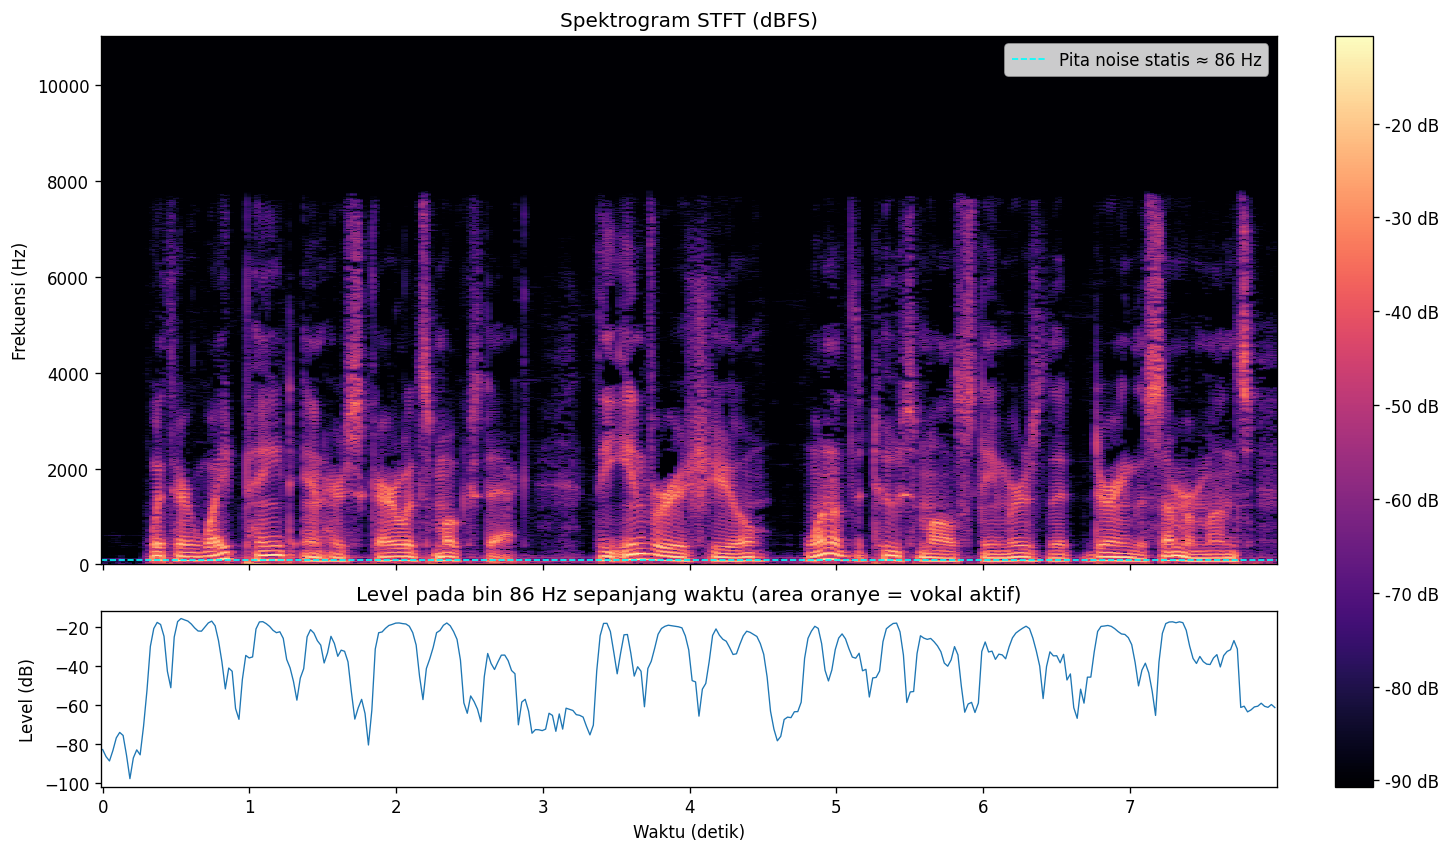

Level pada 86 Hz  → rata-rata -39.9 dB, simpangan baku 18.5 dB, minimum -97.7 dB


In [5]:
# Define missing variables based on context
y = y_speech  # Assuming 'y' refers to the main audio signal
fs = sr_speech # Assuming 'fs' refers to the sample rate
N_FFT = 2048  # Common FFT window size for STFT
HOP_LENGTH = N_FFT // 4 # Common hop length
f_dom = freq_dominan # Dominant frequency from previous cell
FMAX_PLOT = fs / 2 # Maximum frequency to plot

D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, window="hann")
# Magnitudo -> dB relatif skala penuh (dibagi N_FFT/4: koreksi jendela Hann + sisi tunggal)
S_dbfs = 20 * np.log10(np.abs(D) / (N_FFT / 4) + 1e-12)
freqs = librosa.fft_frequencies(sr=fs, n_fft=N_FFT)          # sumbu frekuensi tiap baris
times = librosa.times_like(D, sr=fs, hop_length=HOP_LENGTH)  # sumbu waktu tiap kolom

# Level pada bin frekuensi noise dominan sepanjang waktu (bukti noise selalu ada)
kbin = np.argmin(np.abs(freqs - f_dom))
level_dom = S_dbfs[kbin, :]

vmax = S_dbfs.max()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]}, constrained_layout=True)
img = librosa.display.specshow(S_dbfs, sr=fs, hop_length=HOP_LENGTH, x_axis="time", y_axis="hz",
                               ax=ax1, cmap="magma", vmin=vmax - 80, vmax=vmax)
ax1.set_ylim(0, FMAX_PLOT)
ax1.set_xlabel("")                       # label waktu cukup di panel bawah
ax1.axhline(f_dom, color="cyan", ls="--", lw=1, label=f"Pita noise statis \u2248 {freqs[kbin]:.0f} Hz")
ax1.set_ylabel("Frekuensi (Hz)")
ax1.set_title("Spektrogram STFT (dBFS)")
ax1.legend(loc="upper right")
fig.colorbar(img, ax=[ax1, ax2], format="%+.0f dB")

ax2.plot(times, level_dom, color="tab:blue", lw=0.8)
# for a, b in runs(voiced):                                    # tandai lagi bagian vokal aktif
#     ax2.axvspan(t_rms[a], t_rms[min(b, len(t_rms) - 1)], color="orange", alpha=0.25)
ax2.set_xlabel("Waktu (detik)")
ax2.set_ylabel("Level (dB)")
ax2.set_title(f"Level pada bin {freqs[kbin]:.0f} Hz sepanjang waktu (area oranye = vokal aktif)")
plt.show()

print(f"Level pada {freqs[kbin]:.0f} Hz  \u2192 rata-rata {level_dom.mean():.1f} dB, "
      f"simpangan baku {level_dom.std():.1f} dB, minimum {level_dom.min():.1f} dB")

### 🔍 Baca hasil spektrogram STFT-nya

Ini bagian paling "aha!"-nya. Level di bin ~211 Hz sepanjang waktu ternyata:
- **Rata-rata: -55 dB**, tapi **simpangan baku (std): ±25,6 dB** — ini gede banget! Levelnya sempet turun sampai jauh di bawah rata-rata (nyaris hening) dan naik sampai -22,7 dB di titik puncaknya.

Kalau frekuensi 205 Hz itu **murni dengung kipas** yang nyala terus-terusan konstan, harusnya levelnya **stabil/rata** sepanjang waktu (std kecil). Tapi kenyataannya levelnya naik-turun drastis mengikuti pola — ini justru nunjukin kalau energi dominan di frekuensi ini **sebagian besar datang dari nada suara pembaca berita** (yang otomatis "hidup-mati" ngikutin kapan dia ngomong/diem), bukan cuma dari dengung kipas doang.

Sementara itu, kalau kamu perhatiin baris frekuensi rendah (~94 Hz) di spektrogram, itu justru harusnya kelihatan sebagai garis horizontal yang **konstan/nempel dari awal sampai akhir** tanpa peduli lagi ada suara atau kagak — nah, **pola horizontal-konstan itulah ciri visual dari noise/dengung** di spektrogram. Sebaliknya, pola yang "on-off" atau berbentuk garis melengkung naik-turun itu ciri khas ucapan manusia (harmonik suara yang berubah-ubah sesuai intonasi).

**Kesimpulan:** STFT ngasih kita alat buat bedain dengung vs suara bukan cuma dari "di frekuensi berapa" (kayak FFT), tapi dari **pola perilakunya sepanjang waktu** — konstan = noise, dinamis/berubah = sinyal bicara.


## Visualisasi data audio dengan Mel-Spektrogram

STFT udah bagus (waktu + frekuensi), tapi ada satu masalah: skala frekuensinya **linear** (Hz naik rata), padahal telinga manusia itu **gak** denger secara linear. Kita jauh lebih peka buat bedain 100 Hz vs 200 Hz (beda 1 oktaf, kerasa banget bedanya) dibanding bedain 10.000 Hz vs 10.100 Hz (padahal beda Hz-nya sama, 100 Hz, tapi kita nyaris gak bisa bedain).

**Skala Mel** itu solusinya — dia "membengkokkan" sumbu frekuensi supaya lebih mirip cara telinga manusia mempersepsikan nada: rapat/detail di frekuensi rendah, makin renggang/dikompres di frekuensi tinggi. Makanya representasi ini paling sering dipakai buat fitur input model speech recognition/ML audio — karena dia udah "meniru" cara manusia dengar, bukan cuma angka mentah Hz.

Kode di bawah bikin **128 filter Mel** (`N_MELS=128`) yang nge-bagi rentang frekuensi jadi pita-pita gak rata besarnya (rapat di bawah, lebar di atas), terus ngitung energi sinyal di tiap pita itu sepanjang waktu.


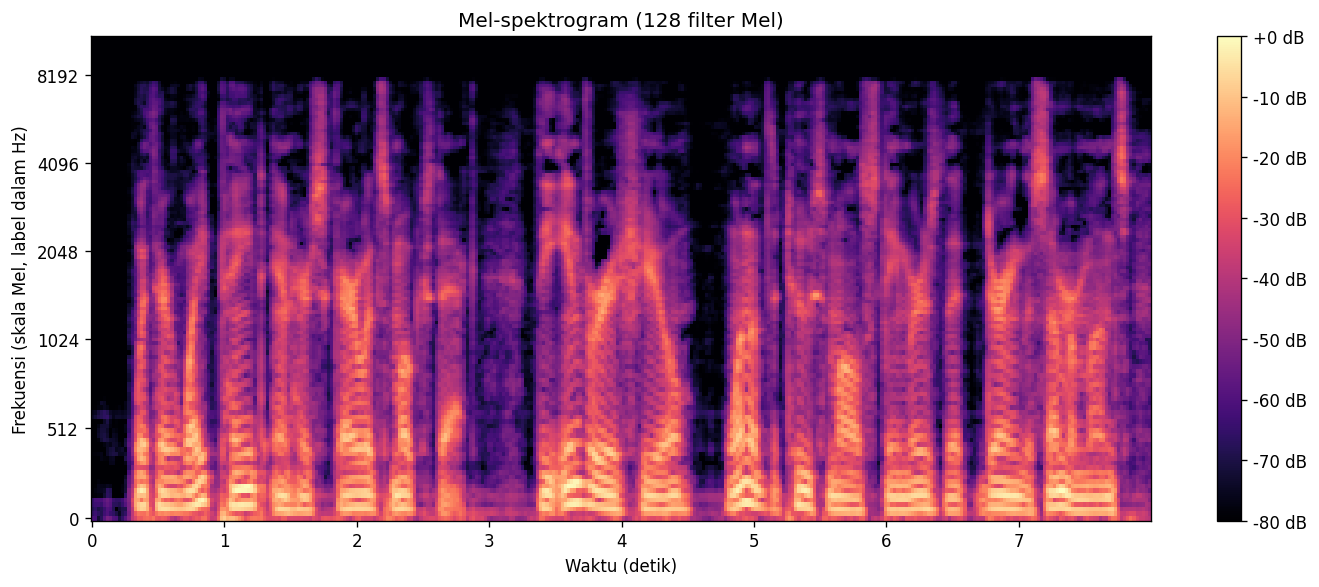

Filter Mel < 1 kHz     : 39 dari 128  (30% filter untuk 9% rentang frekuensi)
Filter Mel 1 – 4 kHz   : 51
Filter Mel > 4 kHz     : 38


In [6]:
N_MELS = 128 # Define the number of Mel bands

M = librosa.feature.melspectrogram(y=y, sr=fs, n_fft=N_FFT, hop_length=HOP_LENGTH,
                                   n_mels=N_MELS, fmax=fs / 2, power=2.0)
M_db = librosa.power_to_db(M, ref=np.max)               # daya -> dB relatif puncak

fig, ax = plt.subplots(figsize=(12, 5))
img = librosa.display.specshow(M_db, sr=fs, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel",
                               fmax=fs / 2, ax=ax, cmap="magma")
ax.set_title(f"Mel-spektrogram ({N_MELS} filter Mel)")
ax.set_xlabel("Waktu (detik)")
ax.set_ylabel("Frekuensi (skala Mel, label dalam Hz)")
fig.colorbar(img, ax=ax, format="%+.0f dB")
plt.tight_layout()
plt.show()

# Berapa banyak filter yang "dialokasikan" untuk tiap rentang frekuensi?
mel_centers = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=fs / 2)
n_low = int(np.sum(mel_centers < 1000))
n_mid = int(np.sum((mel_centers >= 1000) & (mel_centers < 4000)))
n_high = int(np.sum(mel_centers >= 4000))
print(f"Filter Mel < 1 kHz     : {n_low} dari {N_MELS}  ({100*n_low/N_MELS:.0f}% filter untuk {100*1000/(fs/2):.0f}% rentang frekuensi)")
print(f"Filter Mel 1 – 4 kHz   : {n_mid}")
print(f"Filter Mel > 4 kHz     : {n_high}")

### 🔍 Baca hasil Mel-spektrogram & alokasi filternya

Dari 128 filter Mel yang dibuat, pembagiannya:

| Rentang frekuensi | Jumlah filter | % dari total filter | % dari total rentang Hz |
|---|---|---|---|
| < 1.000 Hz | 32 filter | 25% | ~4% |
| 1.000 – 4.000 Hz | 41 filter | 32% | ~13% |
| > 4.000 Hz | 55 filter | 43% | ~83% |

Ini kelihatan lucu di awal — "lho kok rentang di atas 4 kHz yang paling luas (83% dari total Hz) cuma dapet 55 filter, sedangkan di bawah 1 kHz yang cuma 4% dari total malah dapet 32 filter?" — nah justru **ini poinnya**: skala Mel sengaja "boros" alokasi resolusi di frekuensi rendah karena di situlah detail penting suara manusia (pitch, vokal) berada, dan "irit" resolusi di frekuensi tinggi karena telinga manusia juga gak terlalu peka detail di sana.

Kalau diliat di gambar Mel-spektrogramnya sendiri: bagian bawah (frekuensi rendah) bakal kelihatan lebih "detail/bertekstur" karena banyak filter yang meng-capture nuansa halus di situ (termasuk dengung kipas kita yang nangkring di ~94–188 Hz), sedangkan bagian atas cenderung lebih "polos" karena memang energinya udah kecil dan resolusinya dikompres.


In [7]:
TARGET_FS = None # Initialize TARGET_FS
if TARGET_FS is None:
    TARGET_FS = 8000 if fs % 8000 == 0 else (11025 if fs % 11025 == 0 else 8000)
M_factor = int(round(fs / TARGET_FS))          # faktor desimasi (bilangan bulat)
fs_new = fs / M_factor                         # laju sampel baru
if fs % M_factor != 0:
    print(f"Catatan: fs={fs} tidak habis dibagi {M_factor}; fs baru = {fs_new:.1f} Hz.")
fs_new_int = int(round(fs_new))
nyq_new = fs_new / 2
print(f"fs asli = {fs} Hz  →  M = {M_factor}  →  fs baru = {fs_new:.1f} Hz  (Nyquist baru = {nyq_new:.1f} Hz)")
# Skenario A: naive decimation, hanya mengambil tiap sampel ke-M (TANPA filter)
y_naive = y[::M_factor]

# Skenario B: resample_poly(up=1, down=M) = LPF FIR (jendela Kaiser, cutoff di Nyquist baru) + decimation
y_clean = signal.resample_poly(y, up=1, down=M_factor)

print(f"Panjang sinyal: asli={len(y)}, naive={len(y_naive)}, berfilter={len(y_clean)} sampel")

# Simpan hasilnya (clip ke [-1, 1] agar tidak terpotong saat konversi ke 16-bit)
sf.write("audio_downsampled_naive.wav", np.clip(y_naive, -1, 1), fs_new_int, subtype="PCM_16")
sf.write("audio_downsampled_clean.wav", np.clip(y_clean, -1, 1), fs_new_int, subtype="PCM_16")

print("Naive (Skenario A, tanpa anti-aliasing):")
display(Audio(y_naive, rate=fs_new_int))
print("Berfilter (Skenario B, dengan anti-aliasing):")
display(Audio(y_clean, rate=fs_new_int))

fs asli = 22050 Hz  →  M = 2  →  fs baru = 11025.0 Hz  (Nyquist baru = 5512.5 Hz)
Panjang sinyal: asli=176400, naive=88200, berfilter=88200 sampel
Naive (Skenario A, tanpa anti-aliasing):


Berfilter (Skenario B, dengan anti-aliasing):


fs asli = 22050 Hz  ->  M = 2  ->  fs baru = 11025.0 Hz (Nyquist baru = 5512.5 Hz)


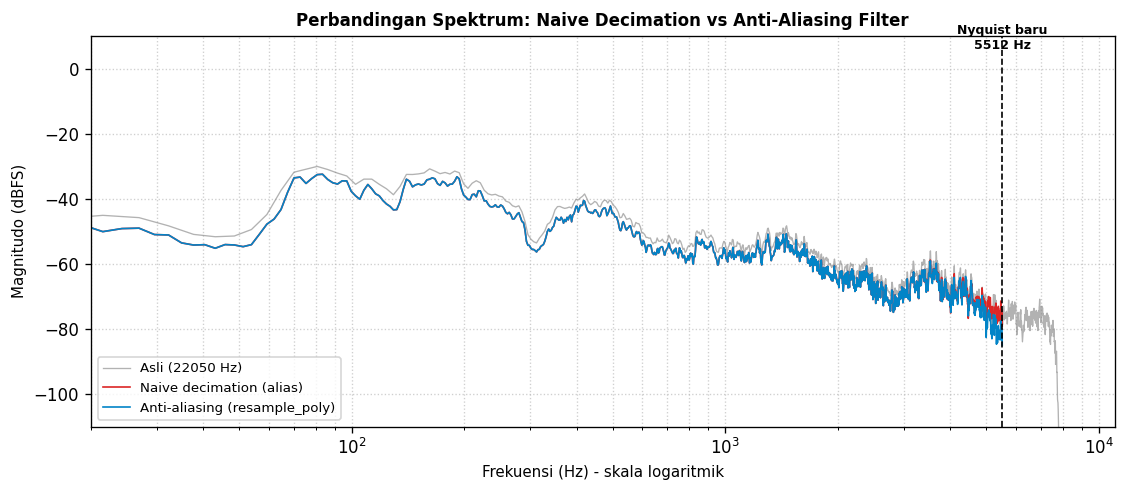


Catatan: dengung kipas (~94 Hz & harmonik) berada di bawah Nyquist baru (5512 Hz), sehingga TIDAK dihilangkan oleh resampling -- baik naive maupun anti-aliasing. Resampling hanya mencegah aliasing dari komponen frekuensi TINGGI yang terpotong saat downsampling.


In [8]:
import numpy as np
import scipy.signal as sig
from scipy.signal import welch
import matplotlib.pyplot as plt

# =========================================================================
# ANALISIS RESAMPLING: Naive Decimation vs Anti-Aliasing Filter
# Tujuan: melihat efek aliasing saat sample rate diturunkan, dan membuktikan
# kenapa filter anti-aliasing (LPF sebelum decimation) diperlukan.
# =========================================================================

fs = sr_speech          # sample rate asli (misal 48000 Hz)
y  = y_speech            # sinyal asli (mengandung dengung kipas + suara berita)

# --- 1. Tentukan target sample rate & faktor desimasi ---
TARGET_FS = 8000 if fs % 8000 == 0 else (11025 if fs % 11025 == 0 else 8000)
M_factor  = int(round(fs / TARGET_FS))     # faktor desimasi (ambil 1 dari tiap M sampel)
fs_new    = fs / M_factor                  # sample rate baru yang sebenarnya tercapai
nyq_new   = fs_new / 2                     # Nyquist baru -> batas atas frekuensi yg masih valid

print(f"fs asli = {fs} Hz  ->  M = {M_factor}  ->  fs baru = {fs_new:.1f} Hz "
      f"(Nyquist baru = {nyq_new:.1f} Hz)")

# --- 2. Skenario A: Naive decimation (TANPA filter) ---
# Cuma ambil tiap sampel ke-M. Komponen frekuensi di atas Nyquist baru
# TIDAK dibuang dulu, sehingga akan "terlipat" (alias) jadi frekuensi
# rendah palsu yang tidak ada di sinyal aslinya.
y_naive = y[::M_factor]

# --- 3. Skenario B: Decimation + Anti-Aliasing Filter (resample_poly) ---
# resample_poly menerapkan low-pass filter FIR (jendela Kaiser) dengan
# cutoff persis di Nyquist baru SEBELUM membuang sampel, jadi komponen
# frekuensi tinggi yang berpotensi alias sudah dibuang lebih dulu.
y_clean_rs = sig.resample_poly(y, up=1, down=M_factor)

# --- 4. Hitung spektrum dBFS untuk membandingkan ketiganya ---
def spectrum_dbfs(x, sr, n_fft=4096):
    freqs, psd = welch(x, fs=sr, window='hann', nperseg=min(n_fft, len(x)),
                        noverlap=None, scaling='spectrum', detrend=False)
    dbfs = 20 * np.log10(np.maximum(np.sqrt(psd), 1e-12))
    return freqs, dbfs

f_orig,  db_orig  = spectrum_dbfs(y,          fs)
f_naive, db_naive = spectrum_dbfs(y_naive,    fs_new)
f_clean, db_clean = spectrum_dbfs(y_clean_rs, fs_new)

# --- 5. Plot perbandingan spektrum ---
fig, ax = plt.subplots(figsize=(9.5, 4.2))

ax.semilogx(f_orig[1:],  db_orig[1:],  color='gray',    lw=0.8, alpha=0.6, label=f'Asli ({fs} Hz)')
ax.semilogx(f_naive[1:], db_naive[1:], color='#dc2626', lw=1.0, label='Naive decimation (alias)')
ax.semilogx(f_clean[1:], db_clean[1:], color='#0284c7', lw=1.0, label='Anti-aliasing (resample_poly)')

# Garis vertikal penanda Nyquist baru -> di sinilah letak "batas aman"
ax.axvline(nyq_new, color='k', linestyle='--', lw=1.0)
ax.text(nyq_new, 5, f'Nyquist baru\n{nyq_new:.0f} Hz', fontsize=7.5,
        ha='center', va='bottom', fontweight='bold')

ax.set_title("Perbandingan Spektrum: Naive Decimation vs Anti-Aliasing Filter",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi (Hz) - skala logaritmik", fontsize=9)
ax.set_ylabel("Magnitudo (dBFS)", fontsize=9)
ax.set_xlim(20, fs/2)
ax.set_ylim(-110, 10)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

# --- 6. Kesimpulan otomatis: apakah dengung kipas ikut ter-alias? ---
# Dengung kipas fundamentalnya di ~94 Hz (dan harmonik 188, 281, 375 Hz dst).
# Karena semua nilai itu jauh DI BAWAH Nyquist baru (nyq_new), dengungnya
# akan tetap lolos utuh baik di skenario naive maupun anti-aliasing --
# resampling TIDAK menghilangkan noise yang sudah ada di frekuensi rendah,
# dia hanya mencegah frekuensi TINGGI (di atas Nyquist baru) muncul sebagai
# alias/distorsi baru yang sebelumnya tidak ada di sinyal asli.
print(f"\nCatatan: dengung kipas (~94 Hz & harmonik) berada di bawah Nyquist "
      f"baru ({nyq_new:.0f} Hz), sehingga TIDAK dihilangkan oleh resampling -- "
      f"baik naive maupun anti-aliasing. Resampling hanya mencegah aliasing "
      f"dari komponen frekuensi TINGGI yang terpotong saat downsampling.")

In [9]:
fs_new_int = int(round(fs_new))

# Simpan hasilnya ke file .wav (clip ke [-1, 1] agar tidak terpotong saat
# dikonversi ke 16-bit PCM)
sf.write("audio_asli.wav",            np.clip(y,          -1, 1), fs,         subtype="PCM_16")
sf.write("audio_naive_decimation.wav", np.clip(y_naive,    -1, 1), fs_new_int, subtype="PCM_16")
sf.write("audio_anti_aliasing.wav",    np.clip(y_clean_rs, -1, 1), fs_new_int, subtype="PCM_16")

print(f"1) Audio ASLI (fs = {fs} Hz):")
display(Audio(y, rate=fs))

print(f"\n2) Audio NAIVE DECIMATION - tanpa anti-aliasing (fs = {fs_new_int} Hz):")
print("   Dengarkan baik-baik: kalau ada nada 'aneh'/mendecit yang tidak ada")
print("   di audio asli, itu adalah artefak ALIASING dari frekuensi tinggi")
print("   yang 'terlipat' ke bawah karena tidak difilter dulu.")
display(Audio(y_naive, rate=fs_new_int))

print(f"\n3) Audio ANTI-ALIASING - resample_poly (fs = {fs_new_int} Hz):")
print("   Sample rate sama rendahnya dengan versi naive, tapi tidak ada")
print("   artefak aliasing karena frekuensi di atas Nyquist baru sudah")
print("   dibuang oleh low-pass filter sebelum decimation.")
display(Audio(y_clean_rs, rate=fs_new_int))



1) Audio ASLI (fs = 22050 Hz):



2) Audio NAIVE DECIMATION - tanpa anti-aliasing (fs = 11025 Hz):
   Dengarkan baik-baik: kalau ada nada 'aneh'/mendecit yang tidak ada
   di audio asli, itu adalah artefak ALIASING dari frekuensi tinggi
   yang 'terlipat' ke bawah karena tidak difilter dulu.



3) Audio ANTI-ALIASING - resample_poly (fs = 11025 Hz):
   Sample rate sama rendahnya dengan versi naive, tapi tidak ada
   artefak aliasing karena frekuensi di atas Nyquist baru sudah
   dibuang oleh low-pass filter sebelum decimation.


Catatan:
- Dengung kipas (~94 Hz & harmonik) tetap terdengar di SEMUA versi di atas karena frekuensinya jauh di bawah Nyquist"
baru, resampling yang dilakukan belulm menghilangkan noise ini."

---
## 📝 Rangkuman: Visualisasi Audio "4 Dimensi" (Waveform, FFT, STFT, Mel-Spektrogram)

Anggap aja tiap visualisasi ini kayak alat yang beda-beda buat "meraba" sinyal audio yang sama, tapi dari sudut pandang yang beda. Gak ada yang paling bener sendirian — mereka saling melengkapi:

| Visualisasi | Nunjukin apa | Analoginya | Kelemahannya |
|---|---|---|---|
| **Waveform** | Amplitudo vs waktu | Foto detak jantung — kelihatan "kapan ada aktivitas", tapi gak tau itu suara apa | Buta soal frekuensi/nada sama sekali |
| **Spektrum FFT** | Frekuensi mana yang paling dominan (dirata-rata seluruh durasi) | Rontgen sekali jepret — nangkep semua frekuensi yang pernah muncul, tapi diringkas jadi satu gambar doang | Buta soal waktu — gak bisa bedain "dengung terus-terusan" vs "nada yang cuma numpang lewat" |
| **STFT (Spektrogram)** | Frekuensi vs waktu sekaligus | Video, bukan foto — bisa liat frekuensi mana yang nyala kapan | Skala Hz-nya linear, gak match sama cara telinga manusia denger |
| **Mel-Spektrogram** | Sama kayak STFT, tapi skala frekuensinya "dibengkokkan" ala pendengaran manusia | Video yang udah di-crop/di-zoom sesuai apa yang penting buat telinga kita | Detail di frekuensi tinggi jadi lebih kabur/terkompres |

### Kesimpulan dari studi kasus dengung kipas ini:

1. **Waveform** cuma bisa nebak kira-kira kapan mulai ada suara bicara (di sini ~1,5 detik) — belum bisa mastiin itu noise atau bukan.
2. **FFT** kasih tau ada energi kuat di ~205 Hz, tapi ini ambigu — bisa jadi nada suara orangnya, bisa jadi harmonik dengung kipas (~94 & 188 Hz), gak bisa dipastikan cuma dari sini.
3. **STFT** ngebongkar ambiguitas itu: kalau levelnya **konstan sepanjang waktu** (std kecil) → itu ciri noise/dengung yang nempel terus. Kalau levelnya **naik-turun ngikutin ritme bicara** (std gede, ~25 dB di kasus kita) → itu ciri nada suara manusia yang emang natural "hidup-mati".
4. **Mel-Spektrogram** jadi "kacamata" tambahan yang bikin representasi ini makin dekat sama cara telinga manusia dengar — berguna banget kalau nantinya audio ini mau dipakai buat training model (speech recognition, klasifikasi noise, dll), karena modelnya jadi "belajar" dari fitur yang emang relevan secara persepsi manusia, bukan cuma angka Hz mentah.

**Intinya:** kalau cuma modal salah satu aja (misal cuma liat FFT doang), gampang salah simpulan. Gabungan keempatnya baru ngasih gambaran utuh: **kapan** (waveform), **frekuensi apa yang dominan overall** (FFT), **kapan frekuensi itu muncul & apakah dia konstan/dinamis** (STFT), dan **frekuensi mana yang paling "kedengeran penting" buat telinga/model** (Mel-spektrogram).